In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os
import pydicom
import matplotlib.pyplot as plt

train_path = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train"

# Get first dicom file
files = os.listdir(train_path)
sample_file = files[0]

sample_path = os.path.join(train_path, sample_file)

print("Showing file:", sample_file)

ds = pydicom.dcmread(sample_path)
img = ds.pixel_array

# Fix inverted images if needed
if ds.PhotometricInterpretation == "MONOCHROME1":
    img = img.max() - img

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()


In [ ]:
import cv2
import numpy as np
import shutil
from tqdm import tqdm

output_dir = "/kaggle/working/jpg_subset"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

max_images = 3000
files = os.listdir(train_path)[:max_images]

for file in tqdm(files):
    dicom_path = os.path.join(train_path, file)
    ds = pydicom.dcmread(dicom_path)
    img = ds.pixel_array.astype(np.float32)

    if ds.PhotometricInterpretation == "MONOCHROME1":
        img = img.max() - img

    # Normalize
    img = (img - img.min()) / (img.max() - img.min())
    img = (img * 255).astype(np.uint8)

    output_path = os.path.join(output_dir, file.replace(".dicom", ".jpg"))
    cv2.imwrite(output_path, img)

print("Converted 20 images ✅")


In [ ]:
import pandas as pd

ann_path = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection/train.csv"
df = pd.read_csv(ann_path)

print("Dataset Shape:", df.shape)
df.head()



In [ ]:
print(df.columns)


In [17]:
labels_dir = "/kaggle/working/labels_yolo"
os.makedirs(labels_dir, exist_ok=True)

images_dir = "/kaggle/working/jpg_subset"

for image_id, group in df.groupby("image_id"):
    
    img_path = os.path.join(images_dir, image_id + ".png")
    if not os.path.exists(img_path):
        continue
        
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    label_path = os.path.join(labels_dir, image_id + ".txt")

    with open(label_path, "w") as f:
        for _, row in group.iterrows():
            
            # Skip "No finding" class if class_id == 14 (check your dataset)
            if row['class_id'] == 14:
                continue
            
            x_min, y_min = row['x_min'], row['y_min']
            x_max, y_max = row['x_max'], row['y_max']

            x_center = ((x_min + x_max) / 2) / w
            y_center = ((y_min + y_max) / 2) / h
            width = (x_max - x_min) / w
            height = (y_max - y_min) / h

            f.write(f"{int(row['class_id'])} {x_center} {y_center} {width} {height}\n")

print("YOLO annotation conversion complete!")


YOLO annotation conversion complete!


In [18]:
import json

coco = {
    "images": [],
    "annotations": [],
    "categories": []
}

# Create categories
class_ids = sorted(df['class_id'].unique())
for cid in class_ids:
    coco["categories"].append({
        "id": int(cid),
        "name": f"class_{cid}"
    })

annotation_id = 1

for image_id, group in df.groupby("image_id"):
    
    img_path = os.path.join(images_dir, image_id + ".png")
    if not os.path.exists(img_path):
        continue
        
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    coco["images"].append({
        "id": image_id,
        "file_name": image_id + ".png",
        "width": w,
        "height": h
    })

    for _, row in group.iterrows():
        
        if row['class_id'] == 14:
            continue

        x_min, y_min = row['x_min'], row['y_min']
        x_max, y_max = row['x_max'], row['y_max']

        coco["annotations"].append({
            "id": annotation_id,
            "image_id": image_id,
            "category_id": int(row['class_id']),
            "bbox": [x_min, y_min, x_max - x_min, y_max - y_min],
            "area": (x_max - x_min) * (y_max - y_min),
            "iscrowd": 0
        })

        annotation_id += 1

with open("/kaggle/working/annotations_coco.json", "w") as f:
    json.dump(coco, f)

print("COCO annotation file created!")


COCO annotation file created!


In [14]:
!pip install pydicom --quiet


In [19]:
import torch
print(torch.__version__)
print("GPU Available:", torch.cuda.is_available())


2.8.0+cu126
GPU Available: False


(np.float64(-0.5), np.float64(2303.5), np.float64(2879.5), np.float64(-0.5))

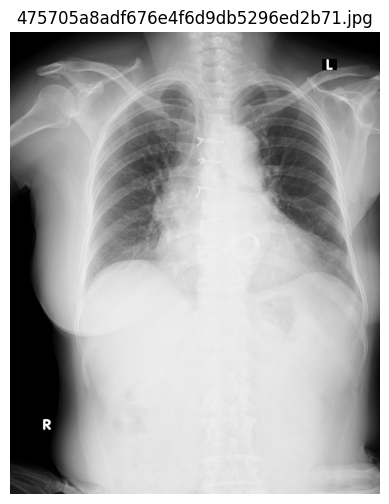

In [20]:
import random
import matplotlib.pyplot as plt

sample_image = random.choice(os.listdir(images_dir))
img = cv2.imread(os.path.join(images_dir, sample_image))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(sample_image)
plt.axis("off")
